# Week 2B. NumPy, Pandas and Visualisation

BCS2143 / BIT3203 Introduction to Artificial Intelligence

Run this notebook in Visual Studio Code using the `.venv` Python kernel. The notebook expects the repository folder to be open in VS Code.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Data toolkit is ready')

Data toolkit is ready


## Exercise 1. NumPy fundamentals
Convert the scores into an array, add five bonus points without a loop, calculate summary statistics, count distinctions and reshape the array into a 2 by 5 matrix.

In [2]:
scores = [56, 78, 92, 88, 45, 67, 73, 81, 90, 60]
arr = np.array(scores)
adjusted = arr + 5
print('Adjusted:', adjusted)
print('Mean:', adjusted.mean())
print('Maximum:', adjusted.max())
print('Standard deviation:', adjusted.std())
print('Distinctions:', (adjusted >= 80).sum())
matrix = arr.reshape(2, 5)
print('Row means:', matrix.mean(axis=1))

Adjusted: [61 83 97 93 50 72 78 86 95 65]
Mean: 78.0
Maximum: 97
Standard deviation: 14.973309587395834
Distinctions: 5
Row means: [71.8 74.2]


## Exercise 2. Load and inspect messy data

In [4]:
from pathlib import Path
data_path = Path('data/students_messy.csv')
if not data_path.exists():
    data_path = Path('../data/students_messy.csv')
df = pd.read_csv(data_path)
display(df.head())
print('Shape:', df.shape)
print('Missing values:')
print(df.isna().sum())
display(df.describe(include='all'))

,student_id,name,age,hours_studied,exam_score,preferred_language,attendance_pct,project_score
0,S001,Aina,20.0,2.5,54.0,Python,82,58
1,S002,Ben,21.0,5.0,71.0,C++,90,73
2,S003,Chong,-4.0,4.0,68.0,Python,88,70
3,S004,Devi,22.0,8.0,84.0,Java,94,87
4,S005,Ethan,240.0,6.5,79.0,Python,91,81


Shape: (15, 8)
Missing values:
student_id            0
name                  0
age                   1
hours_studied         1
exam_score            1
preferred_language    1
attendance_pct        0
project_score         0
dtype: int64


,student_id,name,age,hours_studied,exam_score,preferred_language,attendance_pct,project_score
count,15,15,14.000000,14.000000,14.000000,14,15.000000,15.000000
unique,15,15,NaN,NaN,NaN,4,NaN,NaN
top,S001,Aina,NaN,NaN,NaN,Python,NaN,NaN
freq,1,1,NaN,NaN,NaN,8,NaN,NaN
mean,NaN,NaN,35.357143,6.500000,74.285714,NaN,86.000000,72.600000
std,NaN,NaN,59.305736,6.333671,25.523529,NaN,7.773582,13.086525
min,NaN,NaN,-4.000000,1.000000,45.000000,NaN,68.000000,50.000000
25%,NaN,NaN,20.250000,3.250000,58.500000,NaN,82.500000,62.500000
50%,NaN,NaN,21.500000,5.250000,70.000000,NaN,88.000000,73.000000
75%,NaN,NaN,22.750000,6.875000,79.750000,NaN,91.500000,82.500000


## Exercise 3. Apply documented domain checks
For this teaching exercise, use age 15 to 80, hours studied 0 to 24 and exam score 0 to 100. In a real project, every rule must be justified using domain evidence.

In [5]:
invalid_age = ~df['age'].between(15, 80) & df['age'].notna()
invalid_hours = ~df['hours_studied'].between(0, 24) & df['hours_studied'].notna()
invalid_score = ~df['exam_score'].between(0, 100) & df['exam_score'].notna()
print('Invalid ages')
display(df[invalid_age])
print('Invalid study hours')
display(df[invalid_hours])
print('Invalid exam scores')
display(df[invalid_score])

Invalid ages


,student_id,name,age,hours_studied,exam_score,preferred_language,attendance_pct,project_score
2,S003,Chong,-4.0,4.0,68.0,Python,88,70
4,S005,Ethan,240.0,6.5,79.0,Python,91,81


Invalid study hours


,student_id,name,age,hours_studied,exam_score,preferred_language,attendance_pct,project_score
8,S009,Irfan,22.0,27.0,76.0,JavaScript,83,77


Invalid exam scores


,student_id,name,age,hours_studied,exam_score,preferred_language,attendance_pct,project_score
9,S010,Jia,21.0,7.0,150.0,Python,93,88


## Exercise 4. Clean the dataset
Detect invalid values first, convert them to missing values, then impute. This order prevents impossible values from corrupting the median.

In [6]:
df_clean = df.copy()
df_clean.loc[~df_clean['age'].between(15, 80), 'age'] = np.nan
df_clean.loc[~df_clean['hours_studied'].between(0, 24), 'hours_studied'] = np.nan
df_clean.loc[~df_clean['exam_score'].between(0, 100), 'exam_score'] = np.nan
for column in ['age', 'hours_studied', 'exam_score']:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())
df_clean['preferred_language'] = df_clean['preferred_language'].fillna('Not stated')
display(df_clean)

,student_id,name,age,hours_studied,exam_score,preferred_language,attendance_pct,project_score
0,S001,Aina,20.0,2.5,54.0,Python,82,58
1,S002,Ben,21.0,5.0,71.0,C++,90,73
2,S003,Chong,21.5,4.0,68.0,Python,88,70
3,S004,Devi,22.0,8.0,84.0,Java,94,87
4,S005,Ethan,21.5,6.5,79.0,Python,91,81
5,S006,Farah,20.0,5.0,63.0,C++,85,66
6,S007,Gan,21.5,3.0,57.0,Python,79,59
7,S008,Hana,23.0,9.0,92.0,Python,96,94
8,S009,Irfan,22.0,5.0,76.0,JavaScript,83,77
9,S010,Jia,21.0,7.0,69.0,Python,93,88


## Exercise 5. Visualise the evidence

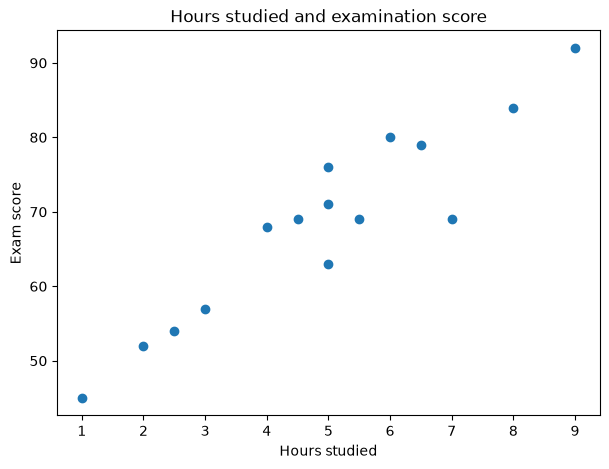

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean['hours_studied'], df_clean['exam_score'])
ax.set_xlabel('Hours studied')
ax.set_ylabel('Exam score')
ax.set_title('Hours studied and examination score')
plt.show()

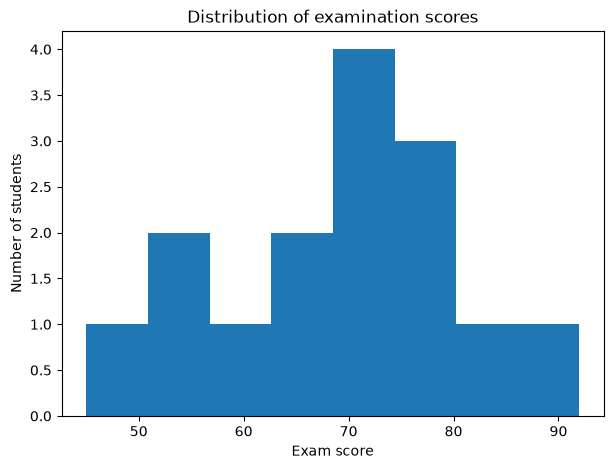

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df_clean['exam_score'], bins=8)
ax.set_xlabel('Exam score')
ax.set_ylabel('Number of students')
ax.set_title('Distribution of examination scores')
plt.show()

## Exercise 6. Prepare the machine-learning variables
Identify the input feature, target variable, possible confounders and one fairness risk.

In [9]:
X = df_clean[['hours_studied']]
y = df_clean['exam_score']
print('Input shape:', X.shape)
print('Target shape:', y.shape)

Input shape: (15, 1)
Target shape: (15,)


## Git checkpoint
After completing and saving the exercises, commit your work using a meaningful message such as `Complete Week 2B data toolkit exercises`.